# Import Library dan Load Datase

In [6]:
import pandas as pd
import numpy as np
import re

In [18]:
import os
import pandas as pd

if os.path.exists('/content'):
    print("Running on Colab")
    base_path = '/content/drive/MyDrive/sentimen_data/Dana_sentimen/'
else:
    print("Running on Local Jupyter")
    base_path = './'
    # buat reviewwer aku pakai jupyter local

Running on Local Jupyter


In [19]:
# Load data hasil scraping
df = pd.read_csv('dataset_dana.csv')

In [20]:
df.head()

,review_text,rating
0,tolong diprpses nosku,5
1,sering ada kendala,2
2,aplikasinya kereeenn,5
3,gimana msh gak bisa juga login,1
4,bagus,5


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   review_text  50000 non-null  object
 1   rating       50000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 781.4+ KB


In [10]:
df.describe()

,rating
count,50000.000000
mean,4.017600
std,1.577156
min,1.000000
25%,3.000000
50%,5.000000
75%,5.000000
max,5.000000


# clening data 

In [11]:
df.columns = df.columns.str.lower().str.strip()
df.columns

Index(['review_text', 'rating'], dtype='object')

In [12]:
import re

def clean_text_basic(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)     
    text = re.sub(r'@\w+|#\w+', '', text)          
    text = re.sub(r'\d+', '', text)               
    text = re.sub(r'[^\w\s]', ' ', text)           
    text = re.sub(r'\s+', ' ', text).strip()       
    return text
    

In [13]:
df['review_text'] = df['review_text'].astype(str)
df['review_text'] = df['review_text'].apply(clean_text_basic)

df.head()

,review_text,rating
0,tolong diprpses nosku,5
1,sering ada kendala,2
2,aplikasinya kereeenn,5
3,gimana msh gak bisa juga login,1
4,bagus,5


In [14]:
def normalize_repeated_chars(text):
    return re.sub(r'(.)\1{2,}', r'\1', text)


df['review_text'] = df['review_text'].apply(normalize_repeated_chars)
df.head()

,review_text,rating
0,tolong diprpses nosku,5
1,sering ada kendala,2
2,aplikasinya kerenn,5
3,gimana msh gak bisa juga login,1
4,bagus,5


In [12]:
df = df[df['review_text'].str.strip() != '']

df['word_count'] = df['review_text'].apply(lambda x: len(x.split())) # hitung jumlah kata

df = df[df['word_count'] >= 3] # filter minimal 3 kata

df.reset_index(drop=True, inplace=True)

print("Jumlah data setelah pembersihan:", len(df))



Jumlah data setelah pembersihan: 28535


In [13]:
import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords
stop_words = set(stopwords.words('indonesian'))

def remove_stopwords(text):
    return ' '.join([w for w in text.split() if w not in stop_words])

df['review_text'] = df['review_text'].apply(remove_stopwords)


[nltk_data] Downloading package stopwords to
[nltk_data]     /home/rizqimaulidiyah/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [14]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

factory = StemmerFactory()
stemmer = factory.create_stemmer()

df['review_text'] = df['review_text'].apply(stemmer.stem)


In [15]:
df = df[df['review_text'].str.strip() != '']
df.reset_index(drop=True, inplace=True)


In [16]:
positive_words = set([
    'bagus', 'baguuus', 'bagussss', 'bgus', 'mantap', 'mantul', 'mantab', 'mntp',
    'top', 'oke', 'ok', 'sip', 'sipp', 'keren', 'hebat', 'terbaik', 'best',
    'recommended', 'rekomen', 'andal', 'andalan', 'jos', 'joss', 'gokil', 'wow',
    'perfect', 'cool', 'ajib', 'mantulity', 'mantappp', 'oke banget', 'sip bgt',
    'mudah', 'gampang', 'cepat', 'lancar', 'praktis', 'simple', 'ringkas',
    'responsif', 'efisien', 'lancar jaya', 'anti lelet', 'fast', 'gercep',
    'satset', 'sat set', 'user friendly', 'ringan', 'hemat kuota', 'ga ribet',
    'gak ribet', 'enggak ribet', 'instan', 'langsung cair', 'ekspres',
    'puas', 'senang', 'suka', 'happy', 'memuaskan', 'ngebantu', 'membantu',
    'berguna', 'bermanfaat', 'untung', 'promo', 'cashback', 'murah', 'hemat',
    'diskon', 'poin', 'reward', 'voucher', 'cuan', 'dapet bonus', 'gratis',
    'bebas admin', 'gratis transfer', 'lumayan', 'berkah',
    'aman', 'stabil', 'normal', 'berfungsi', 'work', 'berhasil', 'sukses',
    'beres', 'selesai', 'fix', 'valid', 'terpercaya', 'amanah', 'safety',
    'no tipu', 'real', 'terjamin', 'premium', 'verified', 'lulus verifikasi',
    'pembayaran', 'transaksi lancar', 'tarik berhasil', 'saldo masuk',
    'cepat cair', 'langsung masuk', 'topup cepat', 'bayar lancar',
    'kirim uang', 'transfer murah', 'dana cicil', 'paylater', 'qris lancar',
    'scan qris', 'dompet digital terbaik', 'tks', 'trims', 'terima kasih'
])

negative_words = set([
    'jelek', 'buruk', 'parah', 'payah', 'kecewa', 'kesal', 'kesel', 'emosi',
    'anjg', 'anjing', 'ajg', 'tai', 'bangsat', 'babi', 'tolol', 'goblok',
    'sampah', 'burik', 'nyesel', 'nyesal', 'kapok', 'asu', 'kontol', 'puki',
    'gembel', 'penipu', 'nipu', 'scam', 'zonk', 'bapuk', 'ampas', 'busuk',
    'gajelas', 'ga jelas', 'ga mutu', 'bobrok', 'kecewa parah',
    'error', 'bug', 'crash', 'hang', 'lag', 'lemot', 'loading', 'forceclose',
    'maintenance', 'gangguan', 'blank', 'item', 'lelet', 'lola', 'lambat',
    'lembab', 'berat', 'boros', 'memori penuh', 'update gagal', 'server rusak',
    'muter terus', 'keluar sendiri', 'tak bisa dibuka', 'buffering',
    'gagal', 'failed', 'tidak berhasil', 'gabisa', 'ga bisa', 'tidak bisa',
    'ga masuk', 'ga jalan', 'sulit', 'ribet', 'susah', 'rumit', 'berbelit',
    'muter muter', 'ditolak', 'reject', 'pending', 'delay', 'tertunda',
    'hilang', 'kepotong', 'ketahan', 'nyangkut', 'saldo berkurang', 'saldo kosong',
    'uang hilang', 'refund lama', 'belum masuk', 'disedot', 'kemana uangnya',
    'blokir', 'keblokir', 'suspend', 'dibekukan', 'logout', 'verifikasi gagal',
    'verif susah', 'otp lama', 'otp ga masuk', 'verifikasi wajah gagal',
    'akun hilang', 'hack', 'hacker', 'phishing', 'muka ga kebaca', 'scan gagal',
    'respon lama', 'cs lama', 'ga direspon', 'tidak direspon', 'bot',
    'pelayanan buruk', 'cs tidak membantu', 'dian ga guna', 'lapor ga respon',
    'komplen diabaikan', 'persulit', 'diputar puter', 'tidak', 'ga', 'gak', 'engga', 'nggak', 'bukan', 'kurang', 'minus',
    'jangan download', 'uninstal', 'hapus', 'bintang satu', 'bintang 1',
    'pelit', 'buang2 kuota', 'kapok pake', 'nyesel bgt'
])

In [17]:
def label_sentiment(text):
    pos, neg = 0, 0
    
    for word in text.split():
        if word in positive_words:
            pos += 1
        elif word in negative_words:
            neg += 1

    if pos > neg:
        return 'positif'
    elif neg > pos:
        return 'negatif'
    else:
        return 'netral'


In [63]:
print(df.columns)

Index(['review_text', 'rating', 'word_count', 'sentiment', 'sentimen',
       'review_text_clean', 'label'],
      dtype='object')


In [64]:
def label_sentiment(text):
    pos = 0
    neg = 0

    for word in text.split():
        if word in positive_words:
            pos += 1
        elif word in negative_words:
            neg += 1

    if pos > neg:
        return 'positif'
    elif neg > pos:
        return 'negatif'
    else:
        return 'netral'
    

df['sentimen'] = df['review_text'].apply(label_sentiment)

In [65]:
print(df.head())
print(df.info())
print(df['sentimen'].value_counts())
print(df['sentimen'].value_counts(normalize=True) * 100)

                                         review_text  rating  word_count  \
0                              tolong diprpses nosku       5           3   
1                               gimana msh gak login       1           4   
2  aplikasi dana buruk transaksi luar kendali kal...       1          17   
3      ok transfer uang tpi sayang fitur dana instan       4           8   
4                                    ok terima kasih       5           3   

  sentiment sentimen                                  review_text_clean  label  
0    netral   netral                              tolong diprpses nosku      1  
1   negatif  negatif                               gimana msh gak login      0  
2   negatif  negatif  aplikasi dana buruk transaksi luar kendali kal...      0  
3   positif  positif      ok transfer uang tpi sayang fitur dana instan      2  
4   positif  positif                                    ok terima kasih      2  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23059 e

 # Exploratory Data Analysis (EDA)

distribusi kelas sentimen

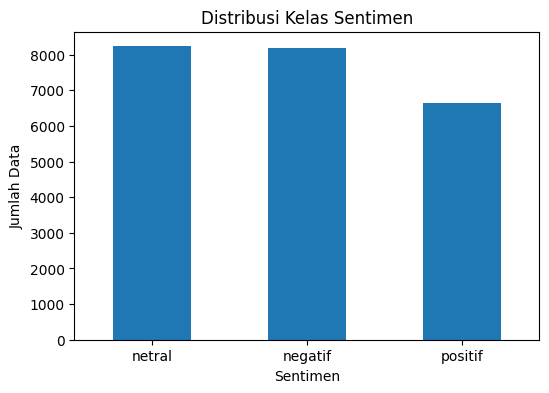

In [66]:
import matplotlib.pyplot as plt

sentiment_counts = df['sentimen'].value_counts()

plt.figure(figsize=(6,4))
sentiment_counts.plot(kind='bar')
plt.title('Distribusi Kelas Sentimen')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah Data')
plt.xticks(rotation=0)
plt.show()

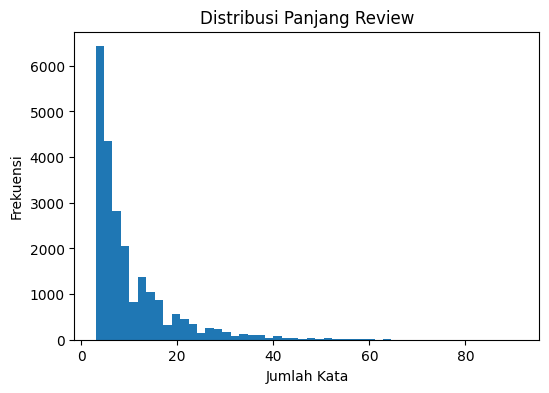

In [67]:
plt.figure(figsize=(6,4))
plt.hist(df['word_count'], bins=50)
plt.title('Distribusi Panjang Review')
plt.xlabel('Jumlah Kata')
plt.ylabel('Frekuensi')
plt.show()

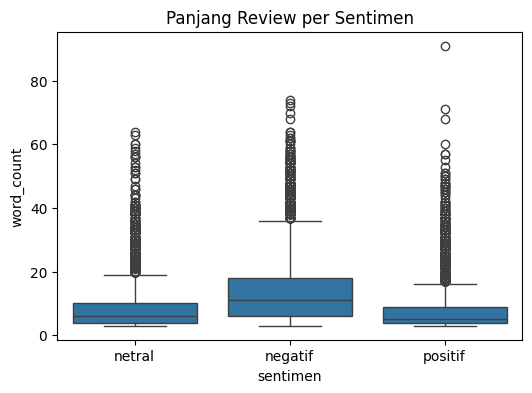

In [68]:
import seaborn as sns

plt.figure(figsize=(6,4))
sns.boxplot(x='sentimen', y='word_count', data=df)
plt.title('Panjang Review per Sentimen')
plt.show()

In [69]:
pd.crosstab(df['rating'], df['sentimen'], normalize='index') * 100

sentimen,negatif,netral,positif
rating,,,
1,58.131098,31.948962,9.919940
2,48.766603,36.369386,14.864010
3,42.838956,41.183959,15.977085
4,29.966997,39.735974,30.297030
5,15.791498,37.093672,47.114830


In [70]:
for s in ['positif', 'netral', 'negatif']:
    print(f"\nContoh {s.upper()}:")
    print(df[df['sentimen'] == s]['review_text'].sample(3).values)


Contoh POSITIF:
['bagus sih tpi aga nge leg' 'puas layan cepat'
 'mantap betol pokok nya dompet digital yg suka suka']

Contoh NETRAL:
['uang gua sedot pdhl gada langgan'
 'gampang dihack uang hilang gk transaksi habis ludes uang ku dihub server gk'
 'dana gua sedott']

Contoh NEGATIF:
['akun dana gak dana cicil nya'
 'akun dana gw oy udh premium jdi akun bot lgi ga'
 'kurang bintang aju dana cicil menu aplikasi tagih pln akun beli token lunas kecewa banget']


# Data Preprocessing
### Ekstraksi Fitur

In [71]:
df = df.dropna(subset=['review_text', 'sentimen'])
df = df.drop_duplicates(subset=['review_text'])

df.reset_index(drop=True, inplace=True)

In [72]:
import re

def clean_text_final(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)          
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)    
    text = re.sub(r'\s+', ' ', text).strip()     
    return text

df['review_text_clean'] = df['review_text'].apply(clean_text_final)

In [73]:
df['word_count'] = df['review_text_clean'].apply(lambda x: len(x.split()))
df = df[df['word_count'] >= 3]

In [74]:
from sklearn.model_selection import train_test_split


X = df['review_text_clean']
y = df['sentimen']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# Percobaan Skema Pelatihan

## skema 1 TF-IDF → SVM


In [173]:
#extraksi fitur TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1,2),
    min_df=5,
    max_df=0.9
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print("Shape train:", X_train_tfidf.shape)
print("Shape test :", X_test_tfidf.shape)

Shape train: (18447, 6589)
Shape test : (4612, 6589)


In [174]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

svm_model = LinearSVC(
    C=1.0,
    class_weight='balanced',
    random_state=42
)

svm_model.fit(X_train_tfidf, y_train)


/home/rizqimaulidiyah/Documents/Project submition/Dana_sentimen/venv/lib/python3.10/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


LinearSVC(class_weight='balanced', random_state=42)

In [175]:
y_pred_svm = svm_model.predict(X_test_tfidf)

print("Akurasi Test SVM:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

Akurasi Test SVM: 0.922376409366869
              precision    recall  f1-score   support

     negatif       0.93      0.95      0.94      1638
      netral       0.91      0.87      0.89      1647
     positif       0.93      0.95      0.94      1327

    accuracy                           0.92      4612
   macro avg       0.92      0.92      0.92      4612
weighted avg       0.92      0.92      0.92      4612



In [176]:
import joblib

joblib.dump(svm_model, "svm_tfidf_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

In [177]:
def predict_sentiment_svm(text):
    text = clean_text_basic(text)
    vec = tfidf.transform([text])
    return svm_model.predict(vec)[0]


## Skema 2 TF-IDF → Logistic Regression

In [178]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_lr = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1,2),
    min_df=5,
    max_df=0.9
)

X_train_tfidf_lr = tfidf_lr.fit_transform(X_train)
X_test_tfidf_lr  = tfidf_lr.transform(X_test)

In [179]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr_model = LogisticRegression(
    C=3.0,
    max_iter=1000,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

lr_model.fit(X_train_tfidf_lr, y_train)

y_pred_lr = lr_model.predict(X_test_tfidf_lr)

print("Akurasi Test Logistic Regression:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))


Akurasi Test Logistic Regression: 0.9269297484822203
              precision    recall  f1-score   support

     negatif       0.94      0.95      0.95      1638
      netral       0.90      0.90      0.90      1647
     positif       0.94      0.93      0.93      1327

    accuracy                           0.93      4612
   macro avg       0.93      0.93      0.93      4612
weighted avg       0.93      0.93      0.93      4612



In [180]:
import joblib

joblib.dump(lr_model, "logreg_tfidf_model.pkl")
joblib.dump(tfidf_lr, "tfidf_logreg_vectorizer.pkl")

['tfidf_logreg_vectorizer.pkl']

In [181]:
def predict_sentiment_lr(text):
    text = clean_text_basic(text)
    vec = tfidf_lr.transform([text])
    return lr_model.predict(vec)[0]

In [182]:
predict_sentiment_lr("aplikasinya membantu tapi sering error")

'negatif'

SKEMA 3 — Deep Learning (Embedding + BiLSTM)

In [183]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

le = LabelEncoder()
y_enc = le.fit_transform(y)
y_cat = to_categorical(y_enc, num_classes=3)

X_train, X_test, y_train, y_test = train_test_split(
    df['review_text_clean'],
    y_cat,
    test_size=0.2,
    random_state=42,
    stratify=y_enc
)

2026-01-13 01:15:06.627726: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-13 01:15:06.709352: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-01-13 01:15:06.709439: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-01-13 01:15:06.710890: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-13 01:15:06.721439: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-13 01:15:06.722564: I tensorflow/core/platform/cpu_feature_guard.cc:1

In [184]:
# token n padding
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_WORDS = 30000
MAX_LEN = 50

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post')
X_test_pad  = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post')


In [185]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Embedding(MAX_WORDS, 128, input_length=MAX_LEN),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


2026-01-13 01:16:36.323972: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:274] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 50, 128)           3840000   
                                                                 
 bidirectional (Bidirection  (None, 128)               98816     
 al)                                                             
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense (Dense)               (None, 64)                8256      
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 3)                 195       
                                                        

In [187]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train_pad, y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
260/260 [==============================] - 24s 94ms/step - loss: 0.0089 - accuracy: 0.9976 - val_loss: 0.0701 - val_accuracy: 0.9783
Epoch 2/10
260/260 [==============================] - 33s 126ms/step - loss: 0.0124 - accuracy: 0.9966 - val_loss: 0.0372 - val_accuracy: 0.9902
Epoch 3/10
260/260 [==============================] - 33s 127ms/step - loss: 0.0106 - accuracy: 0.9968 - val_loss: 0.0530 - val_accuracy: 0.9875
Epoch 4/10
260/260 [==============================] - 34s 130ms/step - loss: 0.0054 - accuracy: 0.9984 - val_loss: 0.0412 - val_accuracy: 0.9913
Epoch 5/10
260/260 [==============================] - 33s 129ms/step - loss: 0.0061 - accuracy: 0.9982 - val_loss: 0.0297 - val_accuracy: 0.9940
Epoch 6/10
260/260 [==============================] - 34s 129ms/step - loss: 0.0043 - accuracy: 0.9987 - val_loss: 0.0516 - val_accuracy: 0.9902
Epoch 7/10
260/260 [==============================] - 34s 130ms/step - loss: 0.0291 - accuracy: 0.9922 - val_loss: 0.0516 - val_acc

In [188]:
loss, acc = model.evaluate(X_test_pad, y_test)
print("Akurasi Test BiLSTM:", acc)

145/145 [==============================] - 2s 15ms/step - loss: 0.0519 - accuracy: 0.9898
Akurasi Test BiLSTM: 0.9898092150688171


# Perbandingan Hasil Model

menguji 3 skema TF-IDF svm dengan logistic regression dan embedding dan BilSTM
kenggulan SVM disebabkan oleh kemampuannya dalam memanfaatkan fitur TF-IDF yang efektif untuk data ulasan pendek dan padat opini. BiLSTM belum menunjukan kinerja optimal karena keterbatasan jumlah datadan panjang teks, sehingga pembelajaran konteks sekuensial belum max. oleh karena itu TF-IDF dengan SVM dipilih sebagai model terbaik.

# Penyimpanan Model

In [189]:
model.save("bilstm_sentiment_model.h5")

import pickle
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

/home/rizqimaulidiyah/Documents/Project submition/Dana_sentimen/venv/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [190]:
from tensorflow.keras.models import load_model
import pickle

model = load_model("bilstm_sentiment_model.h5")

with open("tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)


In [191]:
def predict_sentiment_bilstm(text):
    text = clean_text_basic(text)
    seq = tokenizer.texts_to_sequences([text])
    pad = pad_sequences(seq, maxlen=MAX_LEN, padding='post')
    pred = model.predict(pad)
    label = np.argmax(pred, axis=1)[0]
    return le.inverse_transform([label])[0]

# contoh uji
predict_sentiment_bilstm("aplikasinya membantu tapi sering error")


1/1 [==============================] - 1s 689ms/step


'negatif'

(end)